In [1]:
import numpy as np
import glob
import matplotlib
from sklearn import linear_model
from scipy.signal import hilbert
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

roll_time = 5  #rolling time for probility estimation of the outcome
states_label=[0,1,2]
v_smooth_window=2
lp_f = 25
accuracy_list=[]
accuracy_list2=[]
accuracy_list4=[]
states_linear_output=[]
states_linear_output2=[]
states_linear_output4=[]

sta_all=[]
sta_vx_all=[]
shuffled_indicies = np.random.permutation(42991)
train_data_size = int(42991* 3 / 4)
for stimulus_window in range(10,11,2):
    print(stimulus_window)
    prob_states_mul_lr=[]
    prob_states_lr = []
    prob_states_lr_2=[]
    prob_states_lr_4 = []
    v_x_all =[]
    v_y_all=[]
    for states in states_label:
        #initial_time = [569, 276, 99,184,1776,567,2435,226,1017]
        initial_time = [569, 276, 99,1776,  567, 2435,  141, 109, 204, 400, 377, 206, 170,177, 207, 169]

        videodirectory = 'B:/HsinYi/GitHub/sensory_beh/'
        videoname = '*'
        sensory_dic = videodirectory+'sensory_auto/'
        sensory_roi_files = glob.glob(sensory_dic+ videoname+ '_roi_coordinates_side.npz')
        sensory_stft_files = glob.glob(sensory_dic+ videoname+ '_roi_stft_side.npz')

        labeled_beh = []
        observations = []
        stimulus =[]
        stimulus_all=[]
        stimulus_fly=[]
        stimulus_v_x = []
        stimulus_v_y = []
        stimulus_fly_all=[]
        stimulus_v_x_all = []
        stimulus_v_y_all = []
        observations_fly = []
        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            sensory_stft = np.load(sensory_stft_files[j])

            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            ff_stft = sensory_stft['ff']
            f_spec_fly = sensory_stft['f_spec_fly']
            f_spec_fly_p = sensory_stft['f_spec_fly_p']
            f_spec_spider_p = sensory_stft['f_spec_spider_p']
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2]+roi_spider_list[:, 3]))/2
            #r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r<0.5)[0]]=0.5
            # r=r+0.5
            # r=r/np.max(r)
            x = roi_fly_list[:, 0] + roi_fly_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_fly_list[:, 1] + roi_fly_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)

            ## Load beh

            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
                )

            ## Sensory
            test_divide = np.divide(f_spec_fly, f_spec_fly_p)
            # test_divide = np.mean(test_divide, axis=0)
            t = [i for i in range(int(40 / 2), (nframes - int(40 / 2)), 2)]
            # t= [i for i in range(4000, 6000, 10)]
            # if '0328' in sensory_roi_files[j]:
            #     t.append(5100)
            t = np.array(t)

            t3 = [i for i in range(0, initial_time[j], 1)]
            t3 = np.array(t3)
            yinterp3 = np.interp(t3, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            yinterp3fly = np.interp(t3, t, np.mean(f_spec_fly[0:13, ], axis=0))
            yinterp3fly_mean = np.mean(yinterp3fly)
            yinterp3fly_std = np.std(yinterp3fly)
            yinterp3spider = np.interp(t3, t, np.mean(f_spec_spider_p[0:13, ], axis=0))
            yinterp3spider_mean = np.mean(yinterp3spider)
            yinterp3spider_std = np.std(yinterp3spider)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]

            t2 = np.array(t2)
            #
            yinterp = np.interp(t2, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            yinterpspider = np.interp(t2, t, np.mean(f_spec_spider_p[0:13, ], axis=0))

            yinterpspider = yinterpspider / (np.max(yinterpspider))

            yinterpfly = np.interp(t2, t, np.mean(f_spec_fly[0:13, :], axis=0))
            yinterpfly = (yinterpfly - yinterp3fly_mean) / yinterp3fly_std

            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory  -np.mean(v_x_sensory )) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory  -np.mean(v_y_sensory )) / np.std(v_y_sensory)

            ## Spike trigger average
            from itertools import groupby
            count_dups = [sum(1 for _ in group) for _, group in groupby(beh_hmm)]
            cumsum = np.cumsum(count_dups)

            groups = []
            uniquekeys = []
            for k, g in groupby(beh_hmm):
                groups.append(list(g))  # Store group iterator as a list
                uniquekeys.append(k)

            idx = np.where(np.array(uniquekeys)==states)
            stimulus_temp=[]
            stimulus_temp_fly=[]

            stimulus_v_x_temp = []
            stimulus_v_y_temp = []

            for trigger in range(len(idx[0])):
                if idx[0][trigger]==0:
                    continue
                else:
                    event_time = cumsum[idx[0][trigger]-1]
                    if len(yinterp[event_time - stimulus_window:event_time])==0:
                        stimulus.append(yinterp[0:stimulus_window])
                        stimulus_fly.append(yinterpfly[0:stimulus_window])
                        stimulus_temp.append(yinterp[0:stimulus_window])
                        stimulus_temp_fly.append(yinterpfly[0:stimulus_window])
                        stimulus_v_x.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y.append(v_y_sensory[0:stimulus_window])
                        stimulus_v_x_temp.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y_temp.append(v_y_sensory[0:stimulus_window])
                    else:
                        stimulus.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_fly.append(yinterpfly[event_time - stimulus_window:event_time])
                        stimulus_temp.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_temp_fly.append(yinterpfly[event_time - stimulus_window:event_time])
                        stimulus_v_x.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y.append(v_y_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_x_temp.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y_temp.append(v_y_sensory[event_time - stimulus_window:event_time])


            stimulus_all.append(stimulus_temp)
            stimulus_fly_all.append(stimulus_temp_fly)
            stimulus_v_x_all.append(stimulus_v_x_temp)
            stimulus_v_y_all.append(stimulus_v_y_temp)




            labeled_beh.append(beh_hmm)
            observations.append(list(yinterp))
            observations_fly.append(list(yinterpfly))


        ## Spike trigger average of all videos. Mean centered
        stimulus_test = np.array(stimulus)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)

        train_set = stimulus_test
        sta = np.mean(train_set, axis=0)
        #sta = sta-np.mean(sta)



        stimulus_test = np.array(stimulus_fly)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)

        train_set = stimulus_test
        sta_fly = np.mean(train_set, axis=0)
  

        stimulus_test = np.array(stimulus_v_x)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)

        train_set = stimulus_test
        sta_vx = np.mean(train_set, axis=0)

        stimulus_test = np.array(stimulus_v_y)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)

        train_set = stimulus_test
        sta_vy = np.mean(train_set, axis=0)

        
        sta_all.append(sta)
        

       
        sta_vx_all.append(sta_vx)
       


        ### Step 2: Linear Output

        labeled_beh = []
        observations = []
        observations_fly = []

        linear_output_all=[]
        linear_output_all_fly = []
        linear_output_all_vx = []
        linear_output_all_vy = []
        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            sensory_stft = np.load(sensory_stft_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            ff_stft = sensory_stft['ff']
            f_spec_fly = sensory_stft['f_spec_fly']
            f_spec_fly_p = sensory_stft['f_spec_fly_p']
            f_spec_spider_p = sensory_stft['f_spec_spider_p']
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5
            # r = r + 0.5
            # r = r / np.max(r)
            x = roi_fly_list[:, 0] + roi_fly_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_fly_list[:, 1] + roi_fly_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)

            ## Load beh
          
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
            )

            ## Sensory
            test_divide = np.divide(f_spec_fly, f_spec_fly_p)
            # test_divide = np.mean(test_divide, axis=0)
            t = [i for i in range(int(40 / 2), (nframes - int(40 / 2)), 2)]
            # t= [i for i in range(4000, 6000, 10)]
            # if '0328' in sensory_roi_files[j]:
            #     t.append(5100)
            t = np.array(t)

            t3 = [i for i in range(0, initial_time[j], 1)]
            t3 = np.array(t3)
            yinterp3 = np.interp(t3, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            yinterp3fly = np.interp(t3, t, np.mean(f_spec_fly[0:13, ], axis=0))
            yinterp3fly_mean = np.mean(yinterp3fly)
            yinterp3fly_std = np.std(yinterp3fly)
            yinterp3spider = np.interp(t3, t, np.mean(f_spec_spider_p[0:13, ], axis=0))
            yinterp3spider_mean = np.mean(yinterp3spider)
            yinterp3spider_std = np.std(yinterp3spider)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.interp(t2, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            yinterpspider = np.interp(t2, t, np.mean(f_spec_spider_p[0:13, ], axis=0))

            yinterpspider= yinterpspider / (np.max(yinterpspider))

            yinterpfly = np.interp(t2, t, np.mean(f_spec_fly[0:13, :], axis=0))
            yinterpfly = (yinterpfly - yinterp3fly_mean) / yinterp3fly_std


            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory - np.mean(v_x_sensory)) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory - np.mean(v_y_sensory)) / np.std(v_y_sensory)


            linear_output=[]
            linear_output_fly=[]
            linear_output_v_x=[]
            linear_output_v_y=[]
            for k in range(len(yinterp)-stimulus_window):

                linear_output.append(np.dot(yinterp[k:(k+stimulus_window)],sta))
                linear_output_fly.append(np.dot(yinterpfly[k:(k + stimulus_window)], sta_fly))
                linear_output_v_x.append(np.dot(v_x_sensory[k:(k + stimulus_window)], sta_vx))
                linear_output_v_y.append(np.dot(v_y_sensory[k:(k + stimulus_window)], sta_vy))

            linear_output = np.array(linear_output)
            linear_output_fly = np.array(linear_output_fly)
            linear_output_v_x = np.array(linear_output_v_x)
            linear_output_v_y = np.array(linear_output_v_y)
            linear_output_all.append(linear_output)
            linear_output_all_fly.append(linear_output_fly)
            linear_output_all_vx.append(linear_output_v_x)
            linear_output_all_vy.append(linear_output_v_y)
            labeled_beh.append(beh_hmm[stimulus_window:len(beh_hmm)])

        linear_output_extend=[]
        linear_output_fly_extend = []
        linear_output_vx_extend = []
        linear_output_vy_extend = []
        labeled_beh_extend=[]
        for i in range(len(linear_output_all)):
            linear_output_extend.extend(linear_output_all[i])
            linear_output_fly_extend.extend(linear_output_all_fly[i])
            linear_output_vx_extend.extend(linear_output_all_vx[i])
            linear_output_vy_extend.extend(linear_output_all_vy[i])
            labeled_beh_extend.extend(labeled_beh[i])

        linear_output_sort = np.sort(linear_output_extend)
        ### Step 3: Characterize nonlinearity
        # for i in range(len(linear_output_extend)):
        states_linear_output.append(np.array(linear_output_extend))


        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)

        ##Train multi-classification model with logistic regression

        lr = linear_model.LogisticRegression()
        lr.fit(np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_lr = lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_lr.append(test_x_prob_lr)

        # Train multinomial logistic regression model
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_mul_lr = mul_lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_mul_lr.append(test_x_prob_mul_lr)


        ## 2 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_fly = np.array(linear_output_vx_extend)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_vx_extend)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        lr.fit(np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)

        test_x_prob_lr = lr.predict_proba(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose())
        prob_states_lr_2.append(test_x_prob_lr)
        states_linear_output2.append(np.array(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose()))



        ### 3 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_fly = np.array(linear_output_fly_extend)[shuffled_indicies[:train_data_size]]
        train_x_vx = np.array(linear_output_vx_extend)[shuffled_indicies[:train_data_size]]
        train_x_vy = np.array(linear_output_vy_extend)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_fly_extend)
        test_x_vx = np.array(linear_output_vx_extend)
        test_x_vy = np.array(linear_output_vy_extend)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        #temp = [train_x]+[train_x_fly]+[train_x_vx]+[train_x_vy]
        temp = [train_x] + [train_x_vx] + [train_x_vy]
        temp = np.array(temp)
        lr.fit(temp.transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            temp.transpose(), train_y)
        #temp = [test_x] + [test_x_fly] + [test_x_vx] + [test_x_vy]
        temp = [test_x] + [test_x_vx] + [test_x_vy]
        temp = np.array(temp)
        test_x_prob_lr = lr.predict_proba(temp.transpose())
        prob_states_lr_4.append(test_x_prob_lr)
        states_linear_output4.append(np.array(temp.transpose()))


    prob_temp = np.array(prob_states_lr)
    prob_temp = np.swapaxes(prob_temp, 0, 1)

    idx_list = []
    for i in range(len(prob_temp)):
        idx_list.append(np.where(prob_temp[i,:] == np.max(prob_temp[i,:]))[1][0])
    idx_list =np.array(idx_list)
    accuracy = sum((test_y==np.array(idx_list).astype(int)).astype(int))/len(idx_list)
    print("One feature accuracy = ", accuracy)
    print('One feature F score = ', f1_score(test_y, np.array(idx_list).astype(int), average='micro'))
    accuracy_list.append(accuracy)

    prob_temp_2 = np.array(prob_states_lr_2)
    prob_temp_2 = np.swapaxes(prob_temp_2, 0, 1)

    idx_list_2 = []
    for i in range(len(prob_temp_2)):
        idx_list_2.append(np.where(prob_temp_2[i,:] == np.max(prob_temp_2[i,:]))[1][0])
    idx_list_2 = np.array(idx_list_2)
    accuracy = sum((test_y == np.array(idx_list_2).astype(int)).astype(int)) / len(idx_list_2)
    print("Two features accuracy = ",accuracy)
    print('Two features F score = ', f1_score(test_y, np.array(idx_list_2).astype(int), average ='micro'))
    accuracy_list2.append(accuracy)

    prob_temp_4 = np.array(prob_states_lr_4)
    prob_temp_4 = np.swapaxes(prob_temp_4, 0, 1)
    idx_list_4 = []
    for i in range(len(prob_temp_4)):
        idx_list_4.append(np.where(prob_temp_4[i,:] == np.max(prob_temp_4[i,:]))[1][0])
    idx_list_4 = np.array(idx_list_4)
    accuracy = sum((test_y == np.array(idx_list_4).astype(int)).astype(int)) / len(idx_list_4)
    print("Three features accuracy = ",accuracy)
    print('Three features F score = ', f1_score(test_y, np.array(idx_list_4).astype(int), average ='micro'))
    accuracy_list4.append(accuracy)


from itertools import groupby
spider_beh_predict = np.copy(np.array(idx_list_2))
count_dups = [sum(1 for _ in group) for _, group in groupby( np.array(idx_list_2))]
cumsum= np.cumsum(count_dups)
groups = []
uniquekeys = []
for k, g in groupby( np.array(idx_list_2)):
    groups.append(list(g))      # Store group iterator as a list
    uniquekeys.append(k)
idx = np.arange(0, len(uniquekeys))

count_loop=0
while len(np.where(np.array(count_dups)<15)[0])>0:
    count_loop += 1
    if count_loop > 100:
        break
    spider_beh_predict = np.copy(np.array(spider_beh_predict))
    count_dups = [sum(1 for _ in group) for _, group in groupby(np.array(spider_beh_predict))]
    cumsum = np.cumsum(count_dups)
    groups = []
    uniquekeys = []
    for k, g in groupby(np.array(spider_beh_predict)):
        groups.append(list(g))  # Store group iterator as a list
        uniquekeys.append(k)
    idx = np.arange(0, len(uniquekeys))
    for i in range(len(idx)):
        if count_dups[idx[i]] < 15:
            if idx[i] > 0 and (idx[i] + 1) > len(count_dups):
                if count_dups[idx[i] - 1] - count_dups[idx[i] + 1] > 0:
                    spider_beh_predict[cumsum[(idx[i] - 1)]:cumsum[idx[i]]] = uniquekeys[idx[i] - 1]
                else:
                    spider_beh_predict[cumsum[(idx[i] - 1)]:cumsum[idx[i]]] = uniquekeys[idx[i] + 1]
            else:
                if idx[i] == 0:
                    spider_beh_predict[0:cumsum[(idx[i] + 1)]] = uniquekeys[idx[i] + 1]
                else:
                    spider_beh_predict[cumsum[(idx[i] - 1)]:cumsum[idx[i]]] = uniquekeys[idx[i] - 1]
accuracy = sum((test_y == np.array(spider_beh_predict).astype(int)).astype(int)) / len(idx_list_2)
print(accuracy)
spider_beh_predict = np.copy(np.array(spider_beh_predict))
count_dups = [sum(1 for _ in group) for _, group in groupby(np.array(spider_beh_predict))]
cumsum = np.cumsum(count_dups)
groups = []
uniquekeys = []
for k, g in groupby(np.array(spider_beh_predict)):
    groups.append(list(g))  # Store group iterator as a list
    uniquekeys.append(k)
idx = np.arange(0, len(uniquekeys))


lo = []
lo_normalized = []
lo4 = []
lo4_normalized = []
for i in range(len(labeled_beh_extend)):
    lo.append(states_linear_output2[idx_list_2[i]][i])
    
    lo4.append(states_linear_output4[idx_list_4[i]][i])
    

states_linear_output = np.array(states_linear_output2)
labeled_beh_extend =np.array(labeled_beh_extend)
prob_states_lr_2 =prob_states_lr_2

prob_temp_2 = np.array(prob_states_lr_2)
prob_temp_2 = np.mean(prob_temp_2, axis=0)
lo=np.array(lo)



C:\Users\Gordus_Lab\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


10


B:\TMP\ipykernel_34920\3446361637.py:71: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_34920\3446361637.py:72: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_34920\3446361637.py:264: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_34920\3446361637.py:265: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_34920\3446361637.py:71: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_34920\3446361637.py:72: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_34920\3446361637.py:264: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_34920\3446361637.py:265: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_34920\3446361637.py:71: RuntimeWarning: divide by zero encountered in divid

One feature accuracy =  0.5921937149635971
One feature F score =  0.5921937149635971
Two features accuracy =  0.7386429717847922
Two features F score =  0.7386429717847922
Three features accuracy =  0.73808471540555
Three features F score =  0.73808471540555
0.7518550394268568


In [2]:
len_files=[0,5803, 1469, 1526, 942, 3782, 2565, 1690, 2174, 6826, 2856, 1136, 1438, 2802, 6337, 821, 824]

len_files_cum = np.cumsum(len_files)
observations=[]
sequences=[]
lo=np.array(lo)
for i in range(len(len_files_cum)-1):
    labeled_beh = labeled_beh_extend[len_files_cum[i]:len_files_cum[i+1]]
    labeled_beh = ['' for _ in range(int( labeled_beh_extend[len_files_cum[i]:len_files_cum[i+1]].shape[0]))]
    observations_temp= list(zip(lo[len_files_cum[i]:len_files_cum[i+1],0], lo[len_files_cum[i]:len_files_cum[i+1],1]))
    labeled_data_temp = [(obs, state) for obs, state in zip(observations_temp, labeled_beh)]
    sequences_temp, label_temp = zip(*labeled_data_temp)
    sequences.append(sequences_temp)
    observations.append(list(zip(lo[len_files_cum[i]:len_files_cum[i+1],0], lo[len_files_cum[i]:len_files_cum[i+1],1])))

In [18]:
labeled_beh_extend_str=[]
labeled_beh_extend_num=[]
for i in range(len(labeled_beh_extend)):
    labeled_beh_extend_str.append(str(labeled_beh_extend[i]))
    labeled_beh_extend_num.append(labeled_beh_extend[i])


In [4]:
observation_extend=[]

for i in range(len(observations)):
    observation_extend.extend(observations[i])
len(observation_extend)

42991

In [5]:
len(sequences)

16

In [6]:
len(len_files_cum)

17

In [7]:
    import numpy as np
    from matplotlib.pyplot import get_cmap
    rainbow = get_cmap('rainbow', 256)
    newcolors = rainbow(np.linspace(0, 1, 3))
    newcolors = np.append(newcolors,np.ones((1,4)))
    newcolors =newcolors.reshape(4,4)

    def plot_state_as_color(x_data, state_data,state_data_predict, axis, newcolors, add_labels=True):
        state_current = state_data[0]
        span_left = x_data[0]
        state_encountered = []
        for span_right, state_next in zip(x_data, state_data):
            if np.isnan(state_current):
                state_current = state_next
                continue
            elif state_current != state_next:
                label = None
                if state_current not in state_encountered:
                    state_encountered.append(state_current)
                    if add_labels:
                        label = state_current

                # plot section
                color = int(state_current)
                axis.axvspan(span_left, span_right, ymin=0.5, ymax = 1, facecolor=newcolors[color], alpha=0.2, label=label)

                # Update current state parameters
                span_left = span_right
                state_current = state_next

        state_current_predict = state_data_predict[0]
        span_left_predict = x_data[0]
        state_encountered_predict = []
        for span_right_predict, state_next_predict in zip(x_data, state_data_predict):
            if np.isnan(state_current_predict):
                state_current_predict = state_next_predict
                continue
            elif state_current_predict != state_next_predict:
                label = None
                if state_current_predict not in state_encountered_predict:
                    state_encountered_predict.append(state_current_predict)
                    if add_labels:
                        label = state_current_predict

                # plot section
                color = int(state_current_predict)
                axis.axvspan(span_left_predict, span_right_predict, ymin=0, ymax = 0.5, facecolor=newcolors[color], alpha=0.2, label=label)

                # Update current state parameters
                span_left_predict = span_right_predict
                state_current_predict = state_next_predict



    def plot_state_predict_as_color(x_data, state_data_predict, axis, newcolors, add_labels=True):
        state_current_predict = state_data_predict[0]
        span_left_predict = x_data[0]
        state_encountered_predict = []
        for span_right_predict, state_next_predict in zip(x_data, state_data_predict):
            if np.isnan(state_current_predict):
                state_current_predict = state_next_predict
                continue
            elif state_current_predict != state_next_predict:
                label = None
                if state_current_predict not in state_encountered_predict:
                    state_encountered_predict.append(state_current_predict)
                    if add_labels:
                        label = state_current_predict

                # plot section
                color = int(state_current_predict)
                axis.axvspan(span_left_predict, span_right_predict, ymin=0, ymax = 1, facecolor=newcolors[color], alpha=0.2, label=label)

                # Update current state parameters
                span_left_predict = span_right_predict
                state_current_predict = state_next_predict


In [8]:
import numpy as np
from itertools import groupby

def smooth_state_runs(state_array, min_lengths):
    state_array = np.array(state_array)
    
    # Step 1: Group into (state, length) segments
    grouped = [(state, len(list(group))) for state, group in groupby(state_array)]
    
    # Step 2: Apply smoothing — merge short segments with previous state
    smoothed_states = []
    i = 0
    while i < len(grouped):
        state, length = grouped[i]

        if length < min_lengths.get(state, 0) and i > 0:
            # Merge this short run into the previous state
            # Extend previous segment by this length
            prev_state, prev_length = smoothed_states[-1]
            smoothed_states[-1] = (prev_state, prev_length + length)
        else:
            # Keep current segment as is
            smoothed_states.append((state, length))
        i += 1

    # Step 3: Reconstruct the full array
    result = []
    for state, length in smoothed_states:
        result.extend([state] * length)
    
    return np.array(result)

# Your original array:
hmm_predict_copy = [1]*11 + [2]*164 + [1]*10 + [1]*12 + [1]*7 + [1]*11 + [2]*75 + [2]*204 + [1]*6

# Your thresholds:
thresholds = {0: 30, 1: 30, 2: 30}

smoothed = smooth_state_runs(hmm_predict_copy, thresholds)



In [9]:
def calculate_log_likelihood(y_true, y_pred_proba):
    """
    Calculates the log-likelihood for logistic regression.

    Args:
        y_true (array-like): True labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities of the positive class.

    Returns:
        float: The log-likelihood value.
    """
    # Ensure probabilities are not exactly 0 or 1 to avoid log(0) issues
    y_pred_proba = np.clip(y_pred_proba, 1e-10, 1 - 1e-10)

    log_likelihood = np.sum(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
    return log_likelihood

In [20]:

f1_glm = []
glm_predict_copy_extend=[]
prob_temp = np.array(prob_states_lr_2)
prob_temp = np.swapaxes(prob_temp, 0, 1)

prob = []
for i in range(len(prob_temp)):
    prob.append(np.mean(prob_temp, axis=1)[i, 1])
        
prob = np.array(prob)
for j in range(len(len_files_cum)-1):
#for j in range(3,4):
    temp = lo[len_files_cum[j]:len_files_cum[j+1],:]
    glm = idx_list_2[len_files_cum[j]:len_files_cum[j+1]]
    
    labeled_beh = labeled_beh_extend[len_files_cum[j]:len_files_cum[j+1]]
    prob_temp = prob[len_files_cum[j]:len_files_cum[j+1]]
    



    glm = smooth_state_runs(glm, thresholds)

    
        
        
    count_dups = [sum(1 for _ in group) for _, group in groupby(glm)]
    cumsum= np.cumsum(count_dups)
    if uniquekeys[0]!=0:
        glm[0:count_dups[0]]=0
        

    f1_glm.append(f1_score(labeled_beh,  np.array(glm).astype(int),
                                 average='micro'))
    glm_predict_copy_extend.append(np.array(glm).astype(int))
   

    
    

print(np.mean(f1_glm))

0.723661179721286


In [21]:
### Chance model
import numpy as np

# Example labels (replace with your real one)
labels = np.array(labeled_beh_extend)  # should contain values 0, 1, 2

# Calculate baseline probabilities for each state
unique, counts = np.unique(labels, return_counts=True)
state_probs = counts / len(labels)

# Sanity check: sum should be 1
assert np.isclose(state_probs.sum(), 1), "Probabilities don't sum to 1"

# Unpack for readability
p0, p1, p2 = state_probs

# Random predictions according to baseline class probabilities
random_preds = np.random.choice([0, 1, 2], size=len(labels), p=state_probs)

# Accuracy
accuracy = np.mean(random_preds == labels)
print(f'Random baseline accuracy: {accuracy:.3f}')

# Probability of the true label for each sample
probs = state_probs[labels]  # directly index into the probability array

# Calculate log likelihood (natural log)
log_likelihood = np.sum(np.log(probs))

# Average log likelihood per sample
avg_ll = log_likelihood / len(labels)
print(f"Average Log Likelihood per sample: {avg_ll:.4f}")

# ---------- Per episode ----------
len_files = [0, 5803, 1469, 1526, 942, 3782, 2565, 1690, 2174, 6826, 2856, 1136, 1438, 2802, 6337, 821, 824]
len_files = [x  for x in len_files]
len_files[0] = 0
len_files_cum = np.cumsum(len_files)


glm_fly_beh_chance = []
f1_chance=[]
for i in range(len(len_files_cum) - 1):
    label_temp = labels[len_files_cum[i]:len_files_cum[i+1]]

    # Episode predictions
    predicted_states = np.random.choice([0, 1, 2], size=len(label_temp), p=state_probs)
    f1_chance.append(f1_score(label_temp,  predicted_states,
                                 average='micro'))
    glm_fly_beh_chance.append(predicted_states)

np.mean(f1_chance)

Random baseline accuracy: 0.345
Average Log Likelihood per sample: -1.0801


0.35360866135481545

1.5449101737495915e-06


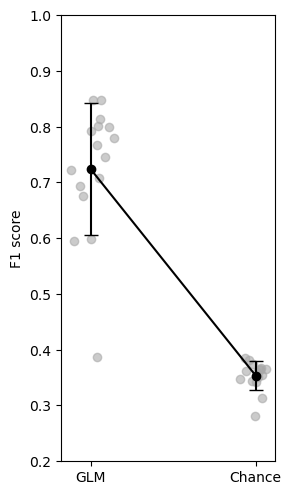

In [22]:
### Plot F1 score
import numpy as np
import matplotlib.pyplot as plt

# Example LL data for 3, 4, and 5 states (replace with your actual data)

# Combine into one array
data = [f1_glm,  f1_chance]
labels = ['GLM',  'Chance']



# Scatter plot
plt.figure(figsize=(3, 5))

for i, ll in enumerate(data):
    x = np.random.normal(i + 0, 0.05, size=len(ll))  # jitter for visibility
    plt.scatter(x, ll, alpha=0.6, label=labels[i], c='darkgray')
    
    # mean = np.mean(ll)
    # std = np.std(ll)
    # plt.errorbar(i + 2, mean, yerr=std, fmt='o', color='black', capsize=5)

data = np.array(data)
data = np.transpose(data)
mean_bic = np.mean(data, axis=0)
sd_bic = np.std(data, axis=0, ddof=1)
states = np.arange(0, 0 + len(mean_bic))
plt.errorbar(states, mean_bic, yerr=sd_bic, fmt='-o',  color='black', capsize=5 )



# Customize axes

plt.xticks([0,1], ('GLM',  'Chance'))
plt.ylabel('F1 score')


plt.xticks(states)
plt.tight_layout()
plt.ylim([0.2, 1])
plt.savefig('GLMHMM-GLM_compare.svg')

from scipy.stats import mannwhitneyu

stat, p_ab = mannwhitneyu(f1_glm, f1_chance, alternative='two-sided')
print(p_ab)